In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv('board2.csv')

# PROBLEM A: VISAYAS COMMUNICATION DATAFRAME

In [46]:
# creates a clean whitespace for the table
df.columns = df.columns.str.strip()

# shows the average column
if 'Average' not in df.columns:
    subject_cols = [col for col in ['Math', 'GEAS', 'Electronics', 'Communication', 'ESAT'] if col in df.columns]
    df['Average'] = df[subject_cols].mean(axis=1)

# conditions to the dataset
vis_comm_condition = (df['Hometown'] == 'Visayas') & (df['Track'] == 'Communication')
VisComm = df[vis_comm_condition][['Name', 'Gender', 'Math', 'Electronics', 'Average']]

# display results
display(VisComm)
print(f"Number of rows: {len(VisComm)}")

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


Number of rows: 5


# PROBLEM B: VISAYAS FEMALE DATAFRAME

In [50]:
# shows average column
if 'Average' not in df.columns:
    df.columns = df.columns.str.strip()
    subjects = [col for col in ['Math', 'GEAS', 'Electronics', 'Communication', 'ESAT'] if col in df.columns]
    df['Average'] = df[subjects].mean(axis=1)

#only shows female from visayas
vis_female_condition = (df['Hometown'] == 'Visayas') & (df['Gender'] == 'Female')

# only keeps the required column
VisFemale = df[vis_female_condition][['Name', 'Track', 'GEAS', 'Electronics', 'Average']]

# displays table of female from visayas
display(VisFemale)

# shows the row of visayan female with average >=60 
display(VisFemale[VisFemale['Average'] >= 60])

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


# PROBLEM C: CATEGORY-AVERAGE VISUALIZATION

 Summary Tables 

Mean Average by Track:


,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500



Mean Average by Gender:


,Gender,Average
0,Female,66.616667
1,Male,67.183333



Mean Average by Hometown:


,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


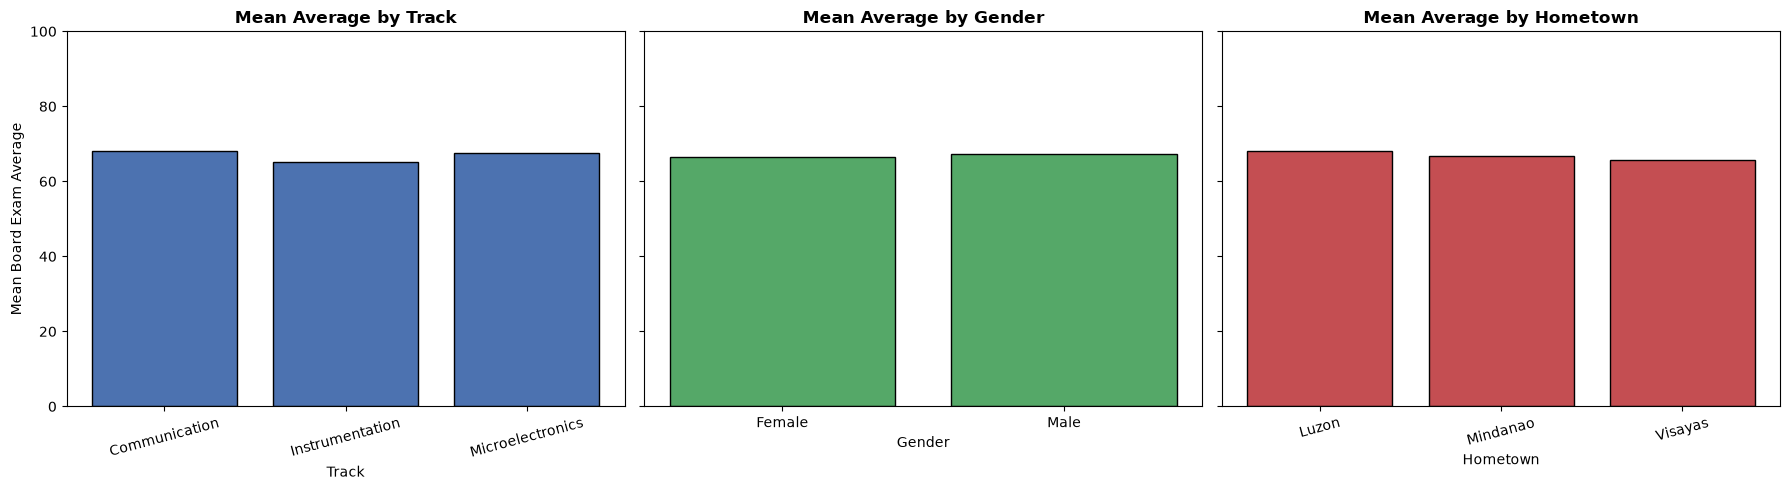


 Observational Interpretation Statements 
1. Base from the dataset, Communication recorded the highest sample mean.
2. Between male and female, Male students recorded the highest sample mean.
3. From the recorded regions, students from Luzon attained the highest sample mean.


In [51]:
df.columns = df.columns.str.strip()
if 'Average' not in df.columns:
    subject_cols = [c for c in ['Math', 'GEAS', 'Electronics', 'Communication', 'ESAT'] if c in df.columns]
    df['Average'] = df[subject_cols].mean(axis=1)

# computes average 
mean_track = df.groupby('Track')['Average'].mean().reset_index()
mean_gender = df.groupby('Gender')['Average'].mean().reset_index()
mean_hometown = df.groupby('Hometown')['Average'].mean().reset_index()

# shows summary tables
print(" Summary Tables ")
print("\nMean Average by Track:")
display(mean_track)

print("\nMean Average by Gender:")
display(mean_gender)

print("\nMean Average by Hometown:")
display(mean_hometown)

# creates three bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# plot 1
axes[0].bar(mean_track['Track'], mean_track['Average'], color='#4C72B0', edgecolor='black')
axes[0].set_title('Mean Average by Track', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Track', fontsize=10)
axes[0].set_ylabel('Mean Board Exam Average', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)

# plot 2
axes[1].bar(mean_gender['Gender'], mean_gender['Average'], color='#55A868', edgecolor='black')
axes[1].set_title('Mean Average by Gender', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=10)
axes[1].tick_params(axis='x', rotation=0)

# plot 3 
axes[2].bar(mean_hometown['Hometown'], mean_hometown['Average'], color='#C44E52', edgecolor='black')
axes[2].set_title('Mean Average by Hometown', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Hometown', fontsize=10)
axes[2].tick_params(axis='x', rotation=15)

# sets y-axis
axes[0].set_ylim(0, 100)

plt.tight_layout()
plt.show()

#interpretation statements
top_track = mean_track.loc[mean_track['Average'].idxmax(), 'Track']
top_gender = mean_gender.loc[mean_gender['Average'].idxmax(), 'Gender']
top_hometown = mean_hometown.loc[mean_hometown['Average'].idxmax(), 'Hometown']

print("\n Observational Interpretation Statements ")
print(f"1. Base from the dataset, {top_track} recorded the highest sample mean.")
print(f"2. Between male and female, {top_gender} students recorded the highest sample mean.")
print(f"3. From the recorded regions, students from {top_hometown} attained the highest sample mean.")